<a href="https://colab.research.google.com/github/k-zannnne/mliot-pyml-2026-hw/blob/main/week01/buoi01_DangNgocKhanhVan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
cau=['Hôm nay tôi làm bài tập đại số tuyến tính',
     'Chúc bạn một ngày mới tốt lành và tràn đầy năng lượng!',
     'Tiếng Việt rất giàu thanh điệu và hình ảnh tượng thanh.',
     'Mùa xuân là mùa của muôn hoa nở rộ.',
     'Thành ngữ là một loại cụm từ cố định, có nghĩa bóng bẩy, biểu thị một ý nghĩa hoàn chỉnh.',
     'Thành ngữ nào dùng để chỉ cách nói năng dài dòng, khó hiểu?',
     'Hôm nay bạn ăn cơm chưa?',
     'Bánh mì là một món ăn đơn giản và ngon'
]
vocab=sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
  v=np.zeros(len(vocab))
  for w in s.lower().split():
    v[vocab.index(w)]+=1
  return v
X=np.array([to_vector(s) for s in cau])
print(X.shape)

(8, 75)


Mỗi hàng đại diện cho một câu, cột đại diện cho số lần xuất hiện của một từ cụ thể trong tập vocab

In [ ]:
X_mean=X.mean(axis=0)
X_s=X-X_mean
print('Shape trước: ', X.shape)
print('Shape sau: ', (X_s).shape)

Shape trước:  (8, 75)
Shape sau:  (8, 75)


In [ ]:
def cosine_similarity(X, Y=None):
  if Y is None:
    Y=X
  Xn=X/np.linalg.norm(X, axis=1, keepdims=True)
  Yn=Y/np.linalg.norm(Y, axis=1, keepdims=True)
  return Xn @ Yn.T
similarity_matrix=cosine_similarity(X)
def search(query, top_k=3):
  query_vec=to_vector(query).reshape(1, -1)
  score=cosine_similarity(X, query_vec)
  score=score.reshape(-1)
  des = np.argsort(score)[::-1][:top_k]
  for i in des:
        print(f"- [Score: {score[i]:}] {cau[i]}")

search('Bánh mì là một món ăn đơn giản', top_k=3)

- [Score: 0.894427190999916] Bánh mì là một món ăn đơn giản và ngon
- [Score: 0.21650635094610968] Thành ngữ là một loại cụm từ cố định, có nghĩa bóng bẩy, biểu thị một ý nghĩa hoàn chỉnh.
- [Score: 0.14433756729740646] Hôm nay bạn ăn cơm chưa?


Cặp 'Bánh mì là một món ăn đơn giản' và 'Bánh mì là một món ăn đơn giản và ngon' là hai cặp giống nhau nhất. Có 3 cặp khác biệt nhất 'Thành ngữ nào dùng để chỉ cách nói năng dài dòng, khó hiểu?', 'Tiếng Việt rất giàu thanh điệu và hình ảnh tượng thanh.', 'Hôm nay tôi làm bài tập đại số tuyến tính' là 3 cặp khác nhau. Kết quả khá khớp với trực giác.

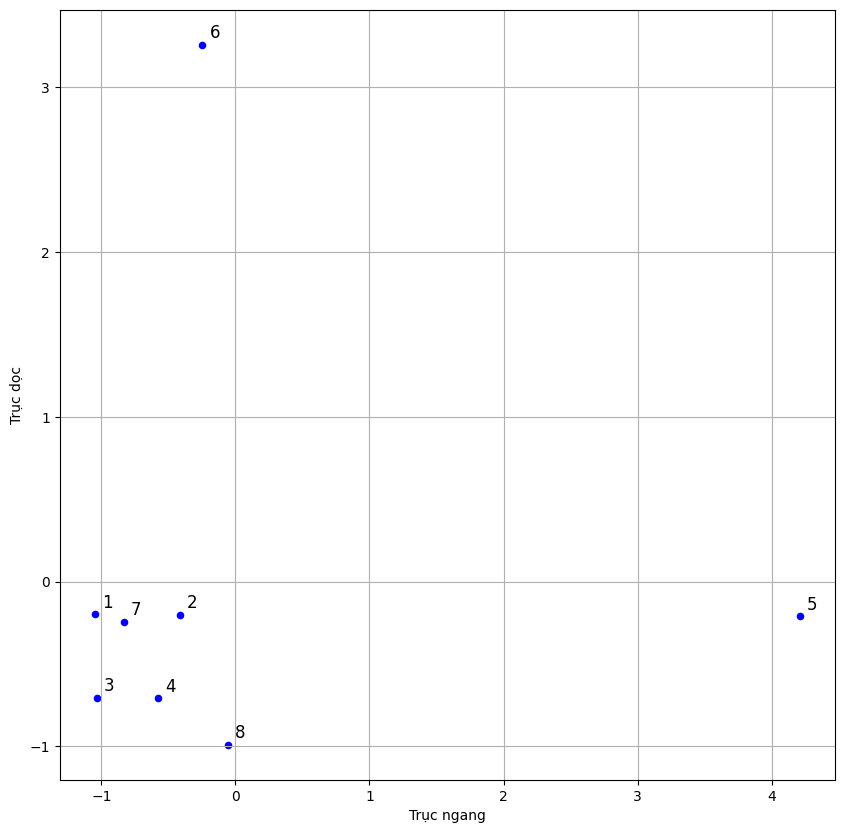

In [ ]:
Xc=X-X.mean(axis=0)
U, S, Vt=np.linalg.svd(Xc, full_matrices=False)
coords=U[:, :2]*S[:2]
plt.figure(figsize=(10, 10))
plt.scatter(coords[:, 0], coords[:, 1], color='blue', s=20)
for i, txt in enumerate(cau):
  plt.annotate(f"{i+1}", (coords[i, 0], coords[i, 1]), fontsize=12, xytext=(5, 5),textcoords='offset points')
plt.xlabel("Trục ngang")
plt.ylabel("Trục dọc")
plt.grid(True)
plt.show()

Các câu có ý nghĩa tương đương nằm gần nhau. Phép toán đại số tuyến tính đã biến đổi dữ liệu từ vựng thô cứng thành một không gian ngữ nghĩa liên tục. Việc các câu tự động gom cụm theo chủ đề trên đồ thị giúp tìm ra bản chất cấu trúc ngôn ngữ dựa trên các "trục thông tin chính" mà không cần phải dán nhãn trước.